# Part 2: Genres and communities and plotting

### *Write about genres and modularity.*

##### *Corresponding text from Week 7 exercise:* ##### 
*Go nuts with an LLM and get all the genres for the nodes in your network*

*Yes, I'm serious. For this one I'd like you to fire up your most powerful thinking model you have access to and get it to write a script to extract genre for all nodes in your network. Some notes to help you*
* *If the node doesn't have an infobox (or if a node's infobox doesn't have a genre it it), just don't assign that node a genre and ignore it in the downstream analysis*
* *Remember to lowercase all genres, also consider simplifying things by mapping rock'n'roll, rock & roll, etc to a single genre.*
* *Remember to test your algorithm well before emplying it, since you're not writing the code yourself, you need to work harder to prove to yourself that it's actually doing what you think it's doing. You should inspect the code to understand what it's actually doing and also test it on the strangest edge-cases you can find. (Can it handle, "The Animals", for example).*
* *The output should be a dictionary mapping artist names to lists of genres (since most artists have multiple genres listed).*

In [140]:
# Add imports
import urllib
import networkx as nx
import io
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from itertools import islice

In order to extract the genre information from all the artists pages, I started by loading the network from Github. Each node contains the name of the artist and its corresponding page content.

In [141]:
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/network.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    network = None

✓ Network loaded successfully!
  Nodes: 484
  Edges: 7676


I converted the directed graph to undirected (as required by *Note: For this and the next exercise, work on the undirected version of the network.*).

In [142]:
network = network.to_undirected()

With the help of an LLM, I defined a function to extract the genre information from each page.

In [143]:
# Helper function to clean the genre text
def clean_genre(genre):
    # Remove reference tags like <ref>...</ref>
    genre = re.sub(r'<ref[^>]*>.*?</ref>', '', genre, flags=re.DOTALL)
    # Remove {{nowrap|...}}
    genre = re.sub(r'\{\{nowrap\|(.*?)\}\}', r'\1', genre)
    # Remove any remaining {{ }}
    genre = re.sub(r'\{\{[^}]*\}\}', '', genre)
    # Remove brackets
    genre = re.sub(r'[\[\]]', '', genre)
    # Clean whitespace
    genre = ' '.join(genre.split())
    # Change to lowercase
    genre = genre.lower().strip()
    
    # Map various rock variants to single genre
    rock_variants = {
        "rock'n'roll": "rock and roll",
        "rock & roll": "rock and roll",
        "rock 'n' roll": "rock and roll",
        "rock n roll": "rock and roll",
        "rock-and-roll": "rock and roll"
    }
    
    if genre in rock_variants:
        return rock_variants[genre]
    
    return genre

# Extract genres list from the wikipedia pages
def extract_genres(content):
    # Parse the JSON structure
    data = json.loads(content)
    
    # Navigate to the wikitext content
    pages = data.get('query', {}).get('pages', {})
    if not pages:
        return []
    
    # Get the page
    page_id = list(pages.keys())[0]
    wikitext = pages[page_id].get('revisions', [{}])[0].get('slots', {}).get('main', {}).get('*', '')
    
    if not wikitext:
        return []
    
    # Extract the Infobox musical artist section
    infobox_pattern = r'\{\{Infobox musical artist(.*?)\n\}\}'
    infobox_match = re.search(infobox_pattern, wikitext, re.DOTALL | re.IGNORECASE)
    
    if not infobox_match:
        return []
    
    infobox_content = infobox_match.group(1)
    
    # Extract genre field
    # Look for | genre = followed by content until the next | field
    genre_pattern = r'\|\s*genre\s*=\s*(.*?)(?=\n\||\n\}\})'
    genre_match = re.search(genre_pattern, infobox_content, re.DOTALL | re.IGNORECASE)
    
    if not genre_match:
        return []

    genre_content = genre_match.group(1).strip()
    
    # Parse genres - they can be in various formats
    genres = []
    
    # Remove {{flatlist| and }} wrappers
    genre_content = re.sub(r'\{\{flatlist\|', '', genre_content, flags=re.IGNORECASE)
    genre_content = re.sub(r'\}\}', '', genre_content)
    
    # Remove wiki formatting like [[Genre]] or [[Genre|display text]]
    # Pattern: [[link]] or [[link|text]]
    wiki_links = re.findall(r'\[\[([^\]|]+)(?:\|[^\]]+)?\]\]', genre_content)
    
    if wiki_links:
        # If we found wiki links, use those
        genres = wiki_links
    else:
        # Otherwise, split by common separators
        # Remove any remaining markup
        genre_content = re.sub(r'<[^>]+>', '', genre_content)
        genre_content = re.sub(r'\*\s*', '', genre_content)
        
        # Split by newlines, commas or bullets
        genre_list = re.split(r'[\n,•]', genre_content)
        genres = [g.strip() for g in genre_list if g.strip()]
    
    # Clean genres
    cleaned_genres = []
    for genre in genres:
        if genre:
            cleaned_genre = clean_genre(genre)
            if cleaned_genre != 'allmusic': # Remove allmusic (discovered during testing)
                cleaned_genres.append(cleaned_genre)
    
    return cleaned_genres

I extracted the genres from each node and added them as a node attribute.

In [144]:
artist_genres = []

for n in network.nodes():
    # Add genres as a list attribute
    genres = extract_genres(network.nodes[n]['content'])
    artist_genres.append(genres)
    network.nodes[n]['genres'] = genres

##### *Corresponding text from Week 7 exercise:* ##### 

*Report the following stats*
* *The number of nodes for which you could find genres*
* *The average number of genres per node*
* *The total number of distinct genres*
* *A histogram showing artist counts for the top 15 genres*

With the help of an LLM, I created a function that generates the above statistics for genres.

In [145]:
# Generate statistics for the nodes with genres
def generate_statistics(nodes_with_genres):
    # 1. Number of nodes with genres
    num_artists_with_genres = len(nodes_with_genres)
    print(f"\n1. Number of artists with genres: {num_artists_with_genres}")
    
    # 2. Average number of genres per node
    total_genres = sum(len(network.nodes[node]['genres']) for node in nodes_with_genres)
    avg_genres = total_genres / num_artists_with_genres if num_artists_with_genres > 0 else 0
    print(f"2. Average number of genres per artist: {avg_genres:.2f}")
    
    # 3. Total number of distinct genres
    all_genres = set()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        all_genres.update(genres)
    num_distinct_genres = len(all_genres)
    print(f"3. Total number of distinct genres: {num_distinct_genres}")
    
    # 4. Top 15 genres histogram
    genre_counter = Counter()
    for node in nodes_with_genres:
        genres = network.nodes[node]['genres']
        genre_counter.update(genres)
    
    top_15 = genre_counter.most_common(15)
    
    print(f"\n4. Top 15 genres:")
    for i, (genre, count) in enumerate(top_15, 1):
        print(f"   {i:2d}. {genre:30s} - {count:3d} artists")
    
    # Create histogram
    if top_15:
        genres_list, counts = zip(*top_15)
        
        plt.figure(figsize=(14, 8))
        bars = plt.barh(range(len(genres_list)), counts, color='steelblue')
        plt.yticks(range(len(genres_list)), genres_list)
        plt.xlabel('Number of Artists', fontsize=12)
        plt.ylabel('Genre', fontsize=12)
        plt.title('Top 15 Genres by Artist Count', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()  # Highest at top
        
        # Add count labels on bars
        for i, (bar, count) in enumerate(zip(bars, counts)):
            plt.text(count + 0.5, i, str(count), va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'num_artists_with_genres': num_artists_with_genres,
        'avg_genres_per_artist': avg_genres,
        'num_distinct_genres': num_distinct_genres,
        'top_15_genres': top_15
    }

I generate statistics for the nodes which I have extracted genres from.


1. Number of artists with genres: 148
2. Average number of genres per artist: 3.72
3. Total number of distinct genres: 144

4. Top 15 genres:
    1. hard rock                      -  33 artists
    2. rock music                     -  32 artists
    3. pop rock                       -  29 artists
    4. alternative rock               -  24 artists
    5. pop music                      -  22 artists
    6. blues rock                     -  22 artists
    7. soft rock                      -  20 artists
    8. folk rock                      -  14 artists
    9. art rock                       -  13 artists
   10. heavy metal music              -  13 artists
   11. rock and roll                  -  13 artists
   12. country rock                   -  12 artists
   13. southern rock                  -  11 artists
   14. indie rock                     -   9 artists
   15. new wave music                 -   9 artists


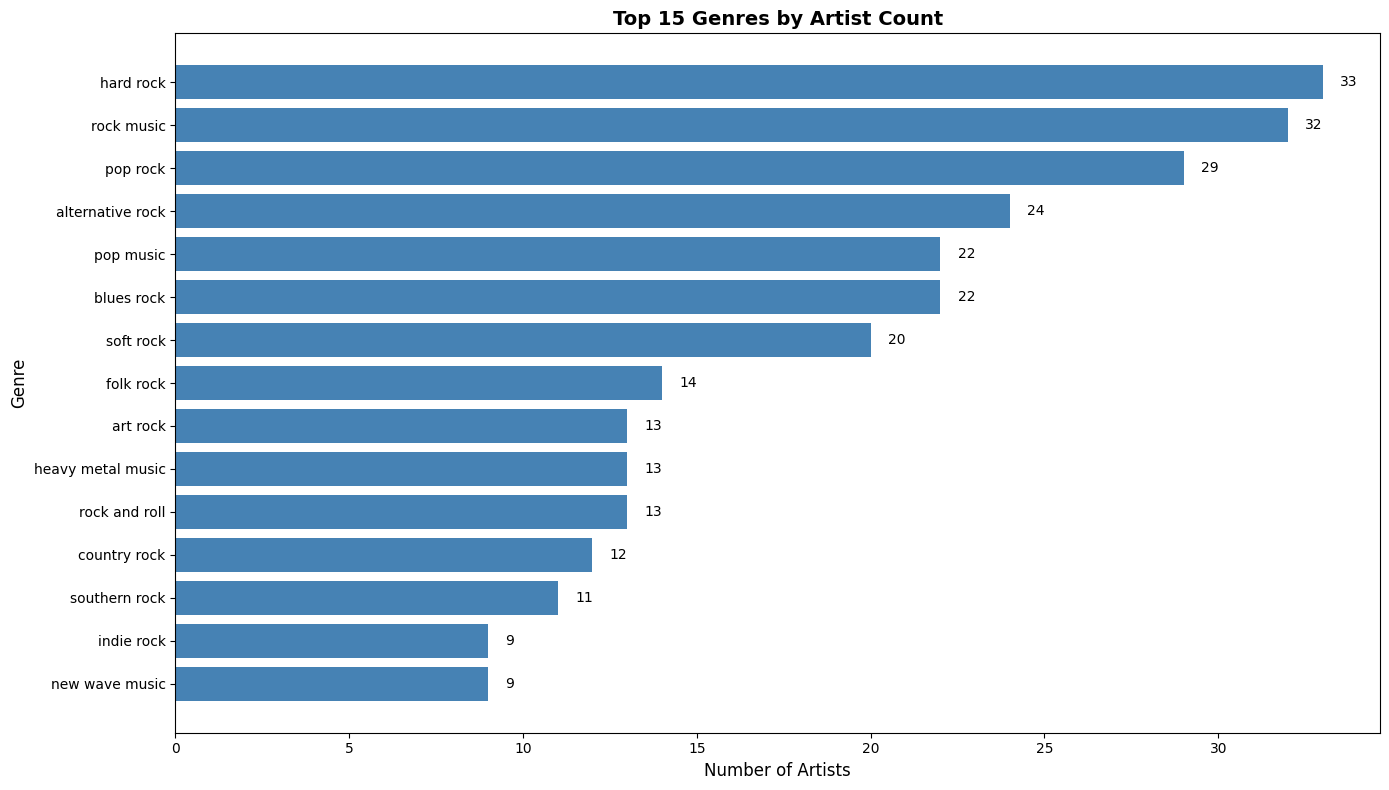

In [146]:
nodes_with_genres = [n for n in network.nodes() if network.nodes[n]['genres']]
stats = generate_statistics(nodes_with_genres)

<center>Figure 1: Top 15 genres by artist count</center>

As expected, the genres are mostly subsets of the rock genre. It can also be observed that Wikipedia considers subgenres of rock but also the broad genres like 'rock music' or 'pop music' when defining the artists. Also an interesting mention is that 'pop music' also appears in the list, so a lot of the artists are actually blending rock and pop music.

For computing modularity, I continue to work with a subnetwork of nodes containing genre information (As required by *Work from the undirected version of the network, keeping only the nodes for which you have genre information.*).

In [147]:
subnetwork = network.subgraph(nodes_with_genres)

##### *Corresponding text from Week 7 exercise:* ##### 

*Explain the concept of modularity in your own words.*

Summarising in my own words what the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity) describes, modularity is a measure of a partition's quality, helping to decide if a community partition is better than another one. The higher is a partition's modularity, the better is the structure of the community it describes. 

Overall, the idea behind modularity's computation is that if there are more links inside a community than you’d expect by chance, then those nodes probably form a real community.

### *Detect the communities, discuss the value of modularity in comparison to the genres.*

##### *Corresponding text from Week 7 exercise:*

*Now create your own partition of the network into genres.*
* *Each node is simply characterized by the first genre in its list of genres.*
* *Each community is the group of nodes that share the same genre.*
* *That's all you need, now calculate the modularity of this division of the network into genres.*
* *Note: Modularity is described in the Network Science book, section 9.4.. Thus, use equation 9.12 in the book to calculate the modularity M of the partition described above. Are the genres good communities?*
*Thinking a bit about the underlying data, a potential issue is the following: Many artists have the genre rock as their first genre in the list (since we started from a list of rock bands). So if rock is a big community, the network won't have very high modularity.*

I first created a partition where each node is characterized by the first genre in its list of genres. Each community is the group of nodes that share the same genre.

In [148]:
# Create a partition based on the first genre in the node's list of genres
def create_first_genre_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if genres:
            labels[node] = genres[0]
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


first_partition = create_first_genre_partition(subnetwork)
# Print the first 3 results
for key, members in islice(first_partition.items(), 3):
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

roots rock (2 members):
  - john fogerty
  - the band

rock and roll (9 members):
  - buddy holly
  - little richard
  - bill haley & his comets
  - fats domino
  - the big bopper
  - mitch ryder
  - the dave clark five
  - chubby checker
  - chuck berry

soft rock (4 members):
  - air supply
  - james taylor
  - five for fighting
  - paul mccartney and wings|wings



I defined a function to compute modularity based on the equation 9.12 from the [Network Science book - Section 9.4](https://networksciencebook.com/chapter/9#modularity:~:text=Section%209.4-,Modularity,-In%20a%20randomly). The modularity is returned with a 2 decimal point precision.

In [149]:
# Compute modularity based on the equation
def calculate_modularity(G, partition):
    # Get total number of edges
    L = G.number_of_edges()
    
    # Calculate modularity
    modularity = 0.0
    
    for community, nodes in partition.items():
        # Calculate lc: number of edges inside this community
        lc = 0
        for i, node_i in enumerate(nodes):
            for node_j in nodes[i+1:]:  # Only check pairs once
                if G.has_edge(node_i, node_j):
                    lc += 1
        
        # Calculate dc: sum of degrees of all nodes in this community
        dc = sum(G.degree(node) for node in nodes)
        
        # Add contribution of this community to modularity
        # Q = Σc [lc/L - (dc/2L)²]
        modularity += (lc / L) - (dc / (2 * L)) ** 2
    
    return round(modularity, 2)

The partition created leads to a slightly higher than 0 modularity, so the option of defining communities by the first genre in the list is suboptimal.

In [150]:
print(calculate_modularity(subnetwork, first_partition))

0.05


##### *Corresponding text from Week 7 exercise:* ##### 

*What happens to the modularity if you use a random genre from the list genre as the node-label for those nodes with more than one genre listed?*

I continued by checking the modularity obtained for a partition defined by a random genre in the node's list of genres.

In [171]:
# Create a partition based on a random genre from the list
def create_genre_random_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if genres:
            labels[node] = random.choice(genres)
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


ranodm_partition = create_genre_random_partition(subnetwork)
# Print the first 3 results
for key, members in islice(ranodm_partition.items(), 3):
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

swamp rock (1 members):
  - john fogerty

pop music (9 members):
  - buddy holly
  - donovan
  - bay city rollers
  - joe cocker
  - the hollies
  - ringo starr
  - dan fogelberg
  - edgar winter|the edgar winter group
  - stevie nicks

pop rock (10 members):
  - air supply
  - crowded house
  - the moody blues
  - the fray
  - bryan adams
  - joe walsh
  - abba
  - the bangles
  - herman's hermits
  - bryan ferry



As expected, the modularity of the random partition is even closer to 0, so it is worse than choosing the first genre from the genre list as a way to define communities.

In [172]:
print(calculate_modularity(subnetwork, ranodm_partition))

0.02


##### *Corresponding text from Week 7 exercise:* ##### 
*Discuss your findings - and decide how you want to settle on a single genre for each band.*

I tested also with the second genre in the list, since I had the assumption that the genres will be slightly less broad but still accurately defining the artist's style. However, on computing the modularity the first genre approach had the highest value. This is because using the second genre splits the communities, resulting in more communities with just 1 or 2 members.

In [153]:
# Create a partition based on the second genre in the node's list of genres
def create_second_genre_partition(G):
    labels = {}
    
    for node in G.nodes():
        genres = G.nodes[node]['genres']
        if len(genres)>1:
            # Set the label as the second genre
            labels[node] = genres[1]
    
    # Create communities based on the assigned genres
    communities = defaultdict(list)
    for node, community in labels.items():
        communities[community].append(node)
    return communities


second_partition = create_second_genre_partition(subnetwork)
# Print the first 3 results
for key, members in islice(second_partition.items(), 3):
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

rock and roll (2 members):
  - john fogerty
  - gary glitter

rockabilly (4 members):
  - buddy holly
  - bill haley & his comets
  - the big bopper
  - duane eddy

pop rock (9 members):
  - air supply
  - the fixx
  - the fray
  - eddie money
  - kaiser chiefs
  - glenn frey
  - reo speedwagon
  - herman's hermits
  - the pretenders



In [154]:
print(calculate_modularity(subnetwork, second_partition))

0.01


##### *Corresponding text from Week 7 exercise:* ##### 

*Again, work only with the subnetwork of nodes that have at least one genre.*
*Use the Louvain-algorithm to find communities for the network. Report the value of modularity found by the algorithm.*
*What is the modularity of this partitioning of the network? Is it more community-like than the genres? What does this comparison reveal about the communities?*

I continued by creating a partition with the help of the Louvain Community Detection Algorithm.

In [155]:
louvain_partition = nx.community.louvain_communities(subnetwork, seed=123)

# Convert the list to a dictionary to use the same calculate_modularity function defined above
louvain_dict = {i+1: list(members) for i, members in enumerate(louvain_partition)}

# Print the first 3 results
for key, members in islice(louvain_dict.items(), 3):
    print(f"{key} ({len(members)} members):")
    for m in members:
        print(f"  - {m}")
    print()

1 (1 members):
  - crash test dummies

2 (1 members):
  - huey lewis and the news

3 (1 members):
  - shakin' stevens



The modularity for the Louvain partition is the highest, defining the partition as optimal.

In [156]:
print(calculate_modularity(subnetwork, louvain_dict))

0.34


### *Calculate the matrix D and discuss your findings.*

##### *Corresponding text from Week 7 exercise:* ##### 

*Compare the communities found by your algorithm with the music genres by creating a matrix D with dimension (GxC), where G is the 7 most common genres and C is the 7 most common communities (if there are fewer than 7 communities, that's fine, then just work with the communities you have). We set entry D(i,j) to be the number of nodes that genre i has in common with community j. The matrix D is what we call a confusion matrix.*
*Use the confusion matrix to explain how well the communities you've detected correspond to the genres.*
* *Note: This time, use all the genres associate with each node*
* *Note: If a node is not characterized by any of the 7 most popular genres, just ignore it.*
* *Note: If a node is not part of by any of the 7 largest (or fewer, if you only have fewer) communities, just ignore it.*

I used an LLM to help with creating the confusion matrix D plotting the 7 most common genres against the 7 largest communities.

In [157]:
def create_D_matrix(partition):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Get top 7 genres
    top_genres = [g for g, _ in stats['top_15_genres'][:7]]

    # Get top 7 communities (by size)
    community_sizes = [(idx, len(c)) for idx, c in enumerate(community_list)]
    community_sizes.sort(key=lambda x: x[1], reverse=True)
    top_community_indices = [idx for idx, _ in community_sizes[:7]]
    top_communities = [community_list[idx] for idx in top_community_indices]

    # Map node to its community index
    node_to_community = {}
    for idx in top_community_indices:
        for node in community_list[idx]:
            node_to_community[node] = idx

    # Initialize confusion matrix
    conf_matrix = np.zeros((7, 7), dtype=int)

    # For each node, count genre-community overlap
    for node in subnetwork.nodes():
        genres = subnetwork.nodes[node]['genres']
        if not genres:
            continue
        # Only consider nodes in top communities
        if node not in node_to_community:
            continue
        comm_idx = top_community_indices.index(node_to_community[node])
        # For each genre, if it is in top genres, increment
        for genre in genres:
            if genre in top_genres:
                genre_idx = top_genres.index(genre)
                conf_matrix[genre_idx, comm_idx] += 1

    # FIX: Get the actual community keys corresponding to top_community_indices
    partition_keys = list(partition.keys())
    community_labels = [f'Community {partition_keys[idx]}' for idx in top_community_indices]
    
    # Create DataFrame for display
    conf_df = pd.DataFrame(conf_matrix, index=top_genres, columns=community_labels)
    print("Confusion Matrix (Genres vs Communities):")
    print(conf_df)

    # Interpretation
    plt.figure(figsize=(8,6))
    sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Community")
    plt.ylabel("Genre")
    plt.title("Confusion Matrix: Genre vs Community")
    plt.show()

I first checked the confusion matrix for the partition defined by the first genre in the genre list.

Confusion Matrix (Genres vs Communities):
                  Community rock music  Community hard rock  \
hard rock                            6                   13   
rock music                          29                    0   
pop rock                             7                    1   
alternative rock                     1                    1   
pop music                           10                    0   
blues rock                           0                    4   
soft rock                            7                    0   

                  Community alternative rock  Community rock and roll  \
hard rock                                  3                        1   
rock music                                 0                        0   
pop rock                                   2                        0   
alternative rock                          10                        0   
pop music                                  0                        2   
blues rock     

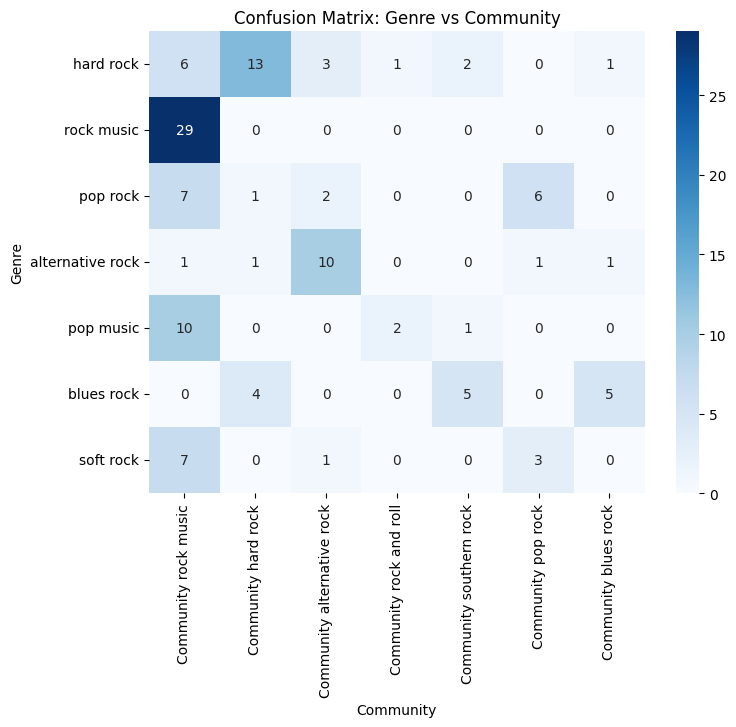

In [158]:
create_D_matrix(first_partition)

<center>Figure 2: Confusion matrix for partition based on first genre in the list</center>

The confusion matrix shows that the communities are accurately corresponding to the genres. Most of the nodes are concentrated in the broad 'rock music' genre, as the first genre in the infobox usually is the broadest genre.
Another interesting observation is that 'southern rock' and 'blues' both contain a higher amount of nodes for the 'blues' genre, as southern rock is a subgenre that blends blues, country and rock.

I also plotted the confusion matrix for the Louvain partition.

Confusion Matrix (Genres vs Communities):
                  Community 14  Community 10  Community 16  Community 11  \
hard rock                    9             7             3             8   
rock music                   8             9            11             2   
pop rock                     9             3            10             2   
alternative rock            15             0             1             5   
pop music                    3             5            12             1   
blues rock                   1             7             2             4   
soft rock                    3             2            11             0   

                  Community 8  Community 5  Community 1  
hard rock                   4            1            0  
rock music                  0            0            0  
pop rock                    0            3            0  
alternative rock            0            1            1  
pop music                   1            0            0  
b

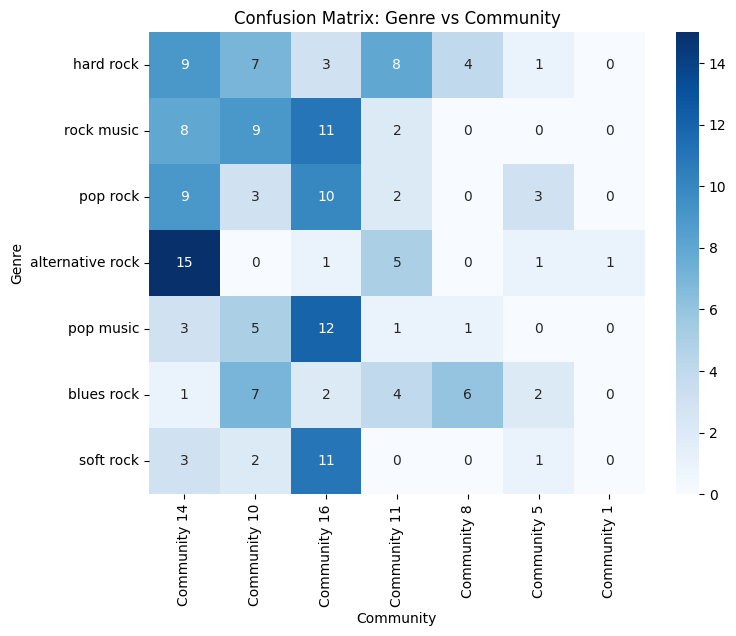

In [159]:
create_D_matrix(louvain_dict)

<center>Figure 3: Confusion matrix for Louvain partition</center>

From the confusion matrix it can be observed that the Louvain partition distributes nodes more widely across genres, as they are not all concentrated on the 'rock music' genre as for the first genre partition.

### *Plot the communities and comment on your results.*

##### *Corresponding text from Week 7 exercise:* ##### 

*Visualize the network, using the Force Atlas algorithm.*
* *This time assign each node a different color based on its structural community.*
* *Note: If there's a lot of small communities, it's OK to only color the 5-10 largest communities (you can make the remaing nodes light gray or some netural color)*
* *Describe the structure you observe.*

With the help of an LLM, I created a function to plot the network with the Force Atlas algorithm.

In [160]:
# Create color map based on partition
def create_color_map(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    # Generate a color for each community
    num_communities = len(community_list)
    color_map = list(mcolors.TABLEAU_COLORS.values())
    while len(color_map) < num_communities:
        color_map += list(mcolors.TABLEAU_COLORS.values())
    colors = color_map[:num_communities]

    # Map node to its community color
    node_colors = []
    node_to_color = {}
    for idx, community in enumerate(community_list):
        for node in community:
            node_to_color[node] = colors[idx]

    for node in subnetwork.nodes():
        node_colors.append(node_to_color.get(node, "#cccccc")) 
    return node_colors

# Plot graph with Force Atlas
def plot_force_atlas(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    partition_keys = list(partition.keys())
    
    # Generate colors
    num_communities = len(community_list)
    color_map = list(mcolors.TABLEAU_COLORS.values())
    while len(color_map) < num_communities:
        color_map += list(mcolors.CSS4_COLORS.values())
    colors = color_map[:num_communities]
    
    # Create color mapping
    node_colors = create_color_map(partition, subnetwork)
    
    # Create layout
    pos = nx.forceatlas2_layout(subnetwork, scaling_ratio=20, gravity=0.1)
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 8))
    nx.draw(subnetwork, pos=pos, node_color=node_colors, ax=ax, 
            with_labels=False, node_size=50)
    
    # Create legend - show top 10 largest communities
    community_sizes = [(idx, key, len(comm)) for idx, (key, comm) in enumerate(partition.items())]
    community_sizes.sort(key=lambda x: x[2], reverse=True)
    
    legend_elements = []
    for idx, key, size in community_sizes[:10]:  # Top 10 communities
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=colors[idx], 
                                         markersize=10, 
                                         label=f'{key} ({size} nodes)'))
    
    ax.legend(handles=legend_elements, loc='upper right', 
             bbox_to_anchor=(1.15, 1), fontsize=9)
    ax.set_title("Force-Atlas layout colored by community", fontsize=16, pad=14)
    plt.tight_layout()
    plt.show()

I plotted based on the first genre partition first.

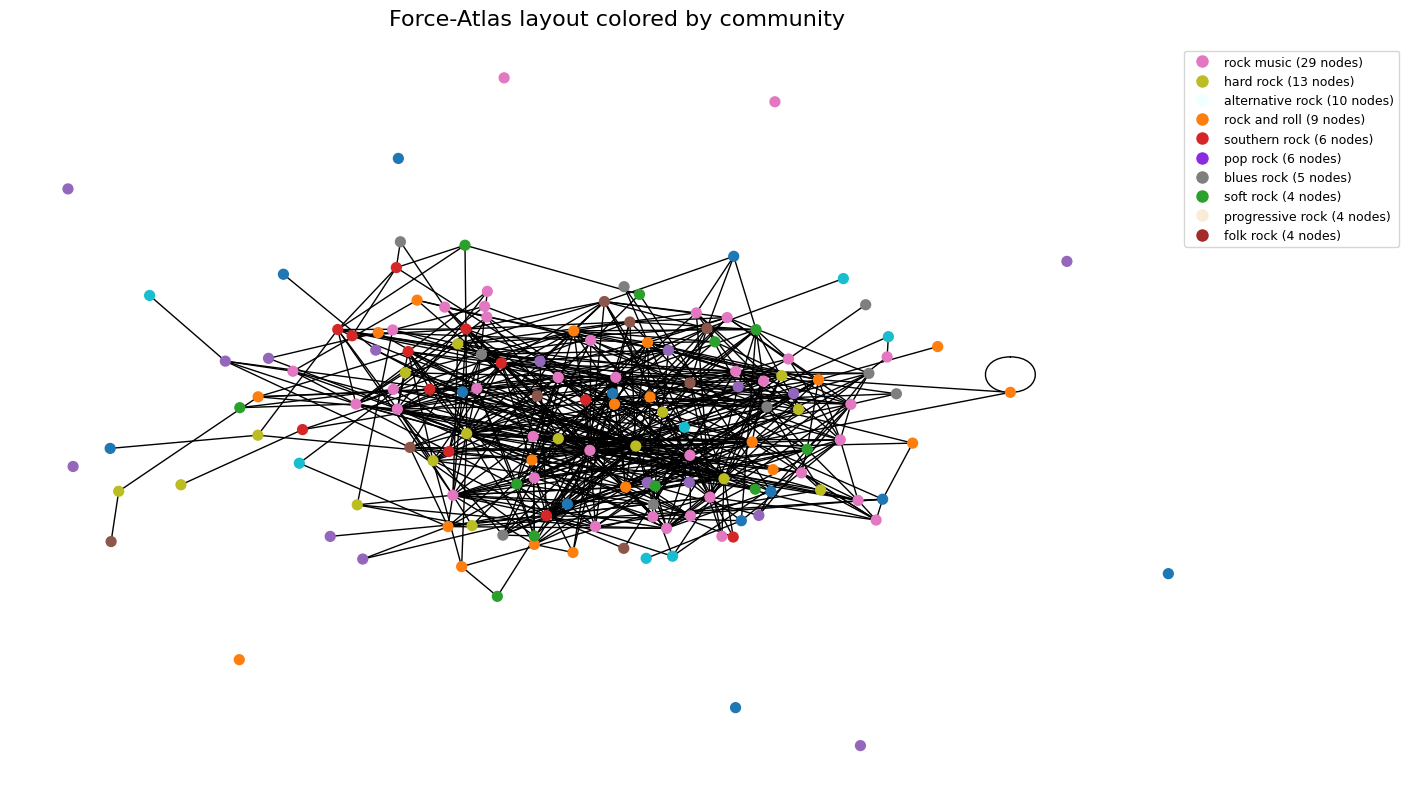

In [161]:
plot_force_atlas(first_partition, subnetwork)

<center>Figure 4: Force-Atlas layout colored by community for the first genre partition</center>

Then, I plotted based on the Louvain partition.

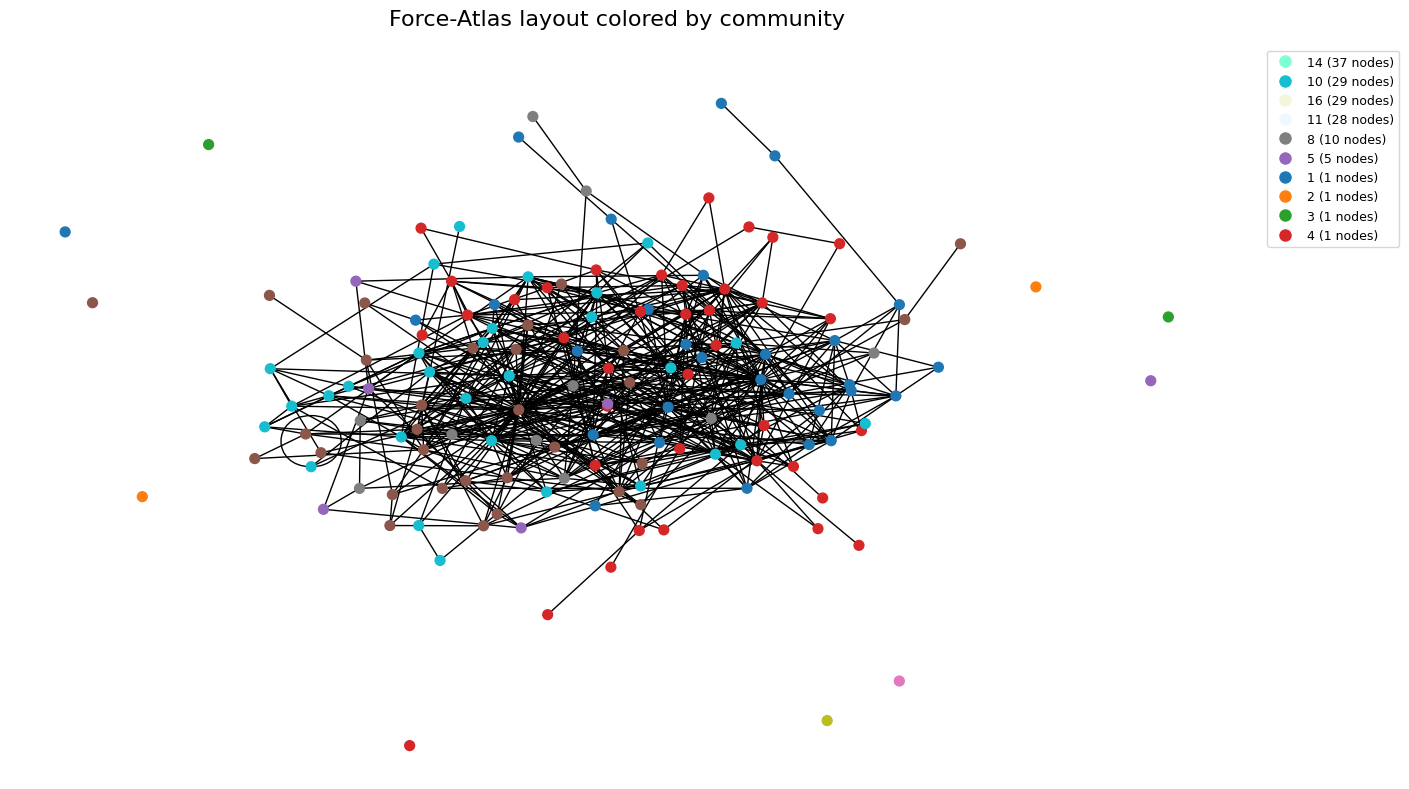

In [162]:
plot_force_atlas(louvain_dict, subnetwork)

<center>Figure 5: Force-Atlas layout colored by community for the Louvain partition</center>

With the help of an LLM, I tried another way to visualise the graphs, which would group the nodes in the same community closer together.

In [163]:
def plot_community_aware(partition, subnetwork):
    # Extract the artists grouped in communities
    community_list = [c for c in partition.values()]
    partition_keys = list(partition.keys())
    
    # Generate a color for each community
    num_communities = len(community_list)
    color_map = list(mcolors.TABLEAU_COLORS.values())
    while len(color_map) < num_communities:
        color_map += list(mcolors.CSS4_COLORS.values())
    colors = color_map[:num_communities]

    # Assign each community a block position
    block_positions = {}
    block_size = 10  # Spread between communities
    for idx, community in enumerate(community_list):
        # Place each block along a circle
        angle = 2 * np.pi * idx / num_communities
        block_positions[idx] = (block_size * np.cos(angle), block_size * np.sin(angle))

    # Assign initial positions for each node based on its community
    init_pos = {}
    for idx, community in enumerate(community_list):
        bx, by = block_positions[idx]
        for node in community:
            # Add small random jitter within the block
            init_pos[node] = (bx + np.random.uniform(-1, 1), by + np.random.uniform(-1, 1))

    # Create color map based on partition
    node_colors = create_color_map(partition, subnetwork)

    # Use spring_layout with these initial positions
    pos = nx.spring_layout(subnetwork, pos=init_pos, seed=42, 
                       k=2.0,  # Increased from 0.5
                       iterations=20)

    pos_scaled = {node: (x * 20, y * 20) for node, (x, y) in pos.items()}

    fig, ax = plt.subplots(figsize=(24, 20))
    nx.draw(subnetwork, pos=pos_scaled, node_color=node_colors, 
        with_labels=False, node_size=150, edge_color="#cccccc", ax=ax)
    
    # Create legend - show top 10 largest communities
    community_sizes = [(idx, key, len(comm)) for idx, (key, comm) in enumerate(partition.items())]
    community_sizes.sort(key=lambda x: x[2], reverse=True)
    
    legend_elements = []
    for idx, key, size in community_sizes[:10]:  # Top 10 communities
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=colors[idx], 
                                         markersize=15, 
                                         label=f'{key} ({size} nodes)'))
    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12)
    ax.set_title("Community-aware layout: nodes in same community are closer", fontsize=16)
    plt.tight_layout()
    plt.show()

I plotted the first genre partition with the spring layout.

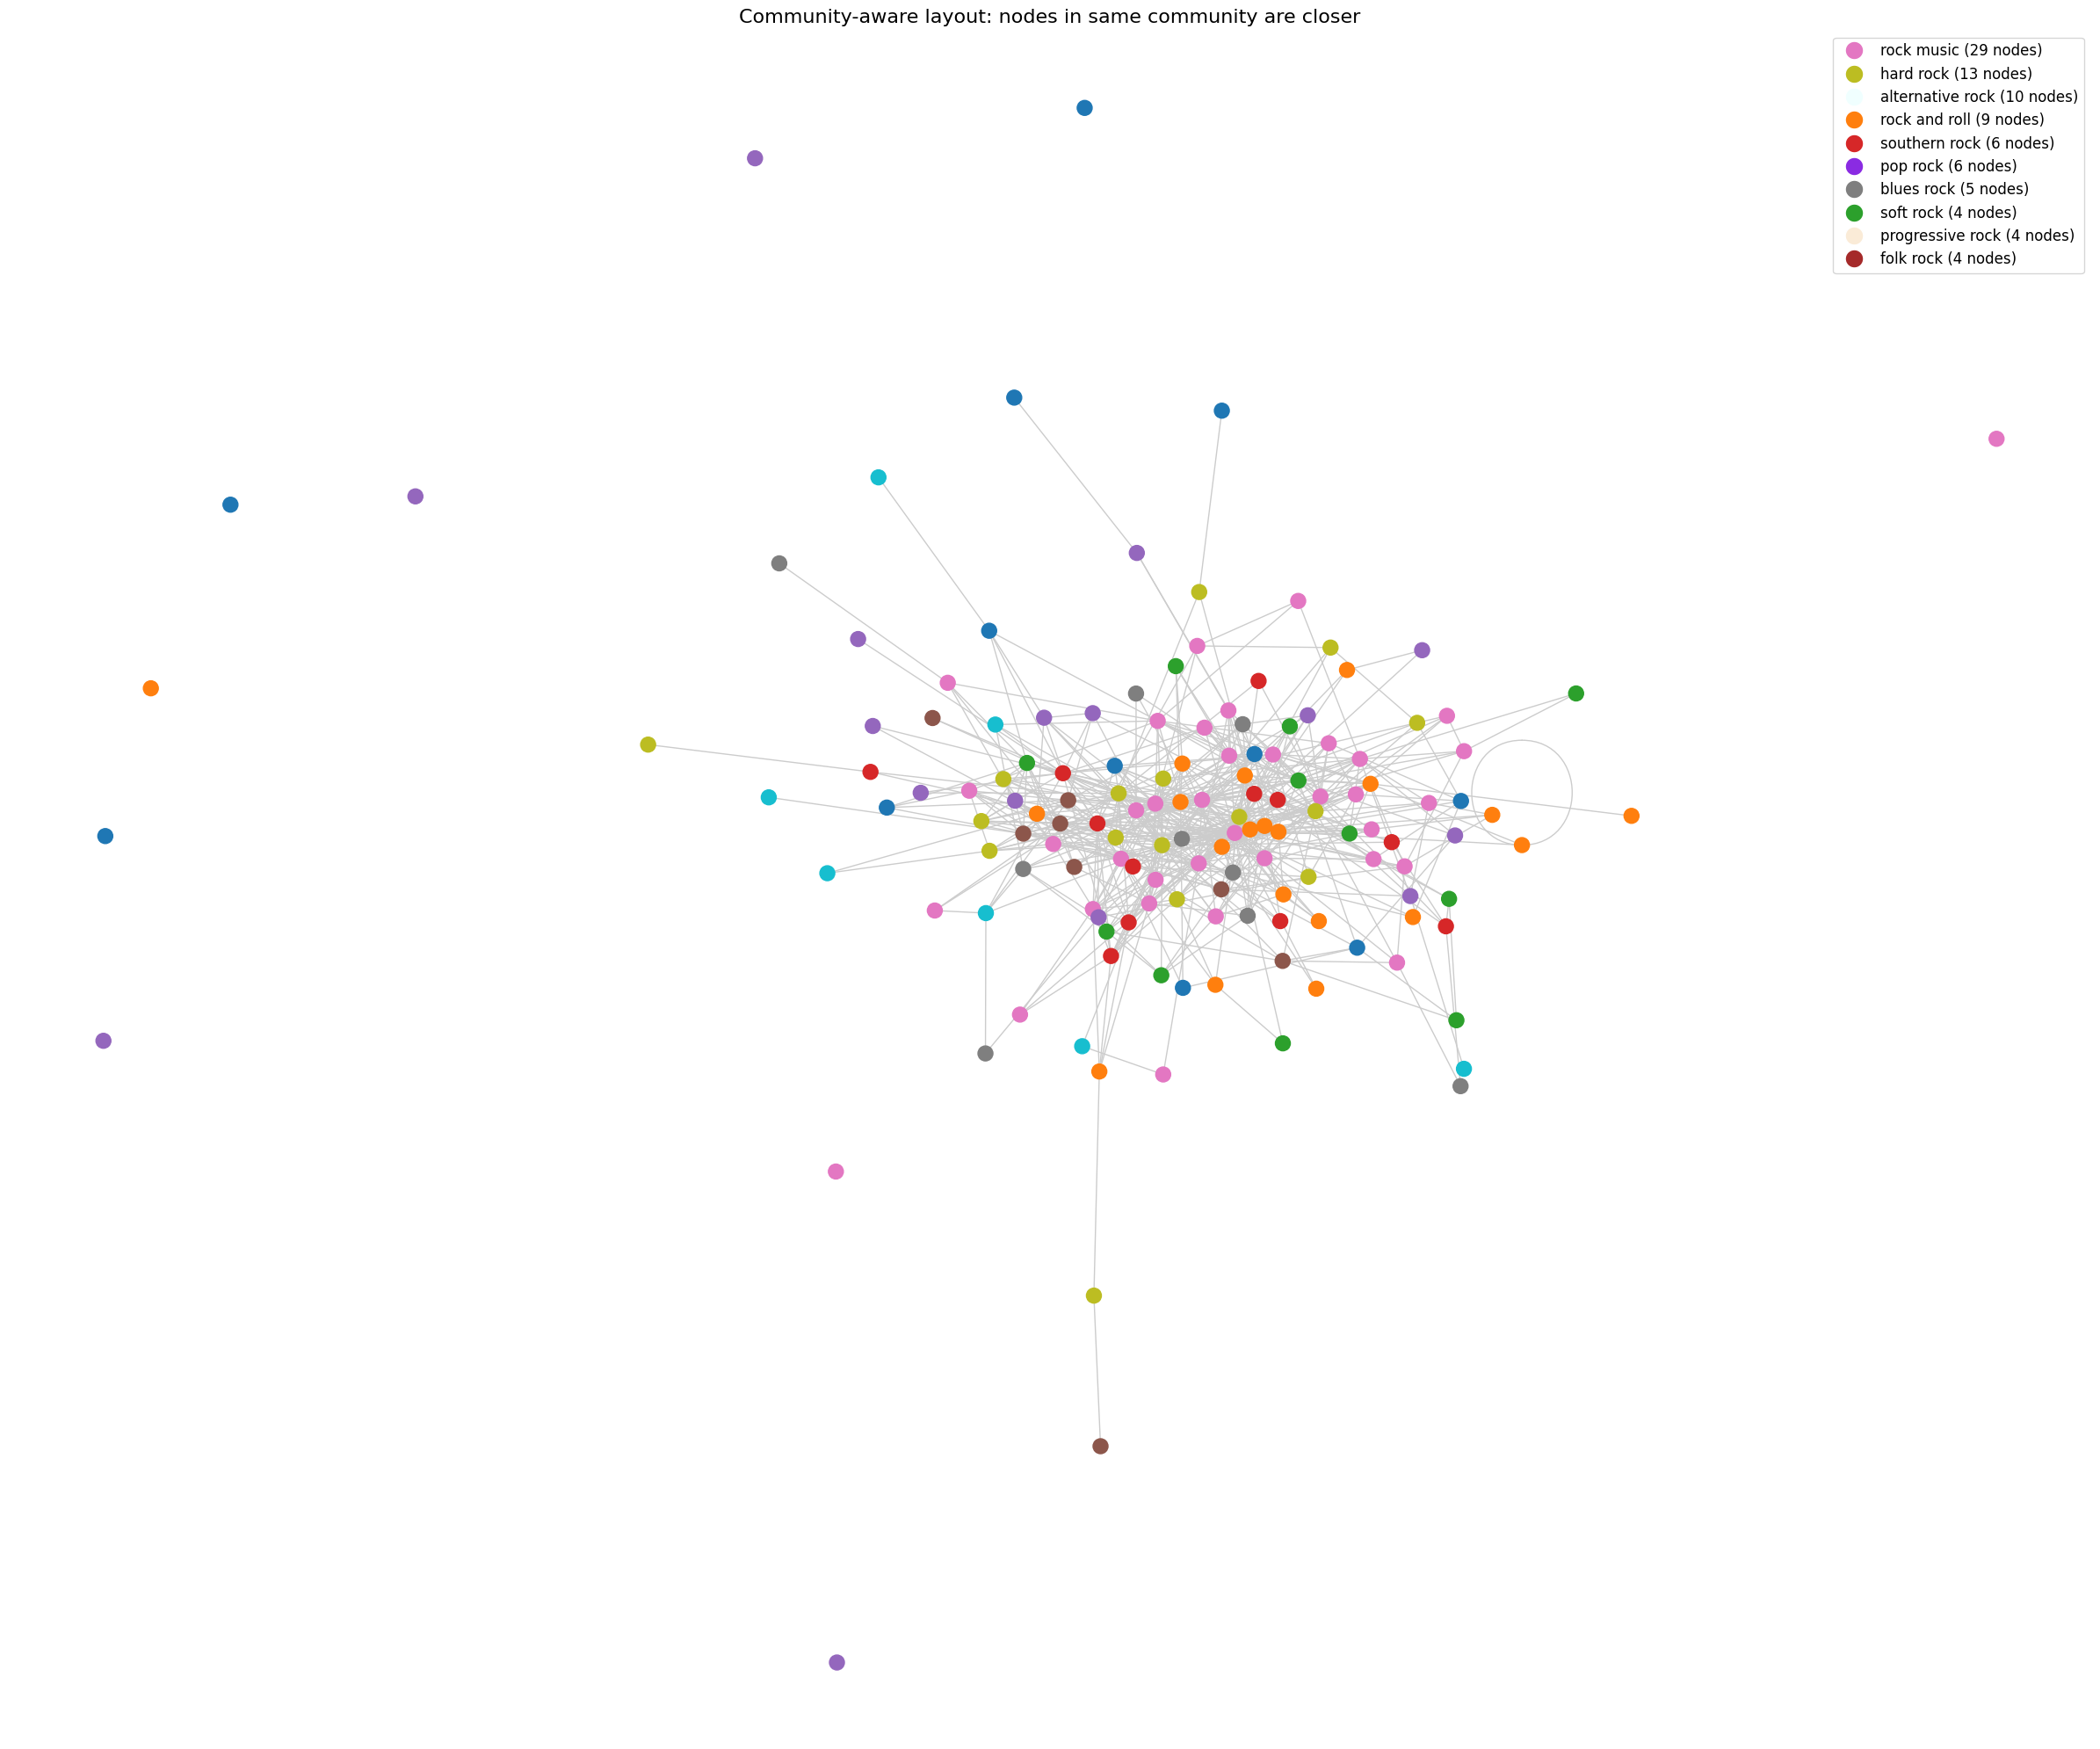

In [164]:
plot_community_aware(first_partition, subnetwork)

<center>Figure 6: Custom layout colored by community for the first genre partition</center>

The updated function works better for visualising the Louvain partition, emphasizing the grouping.

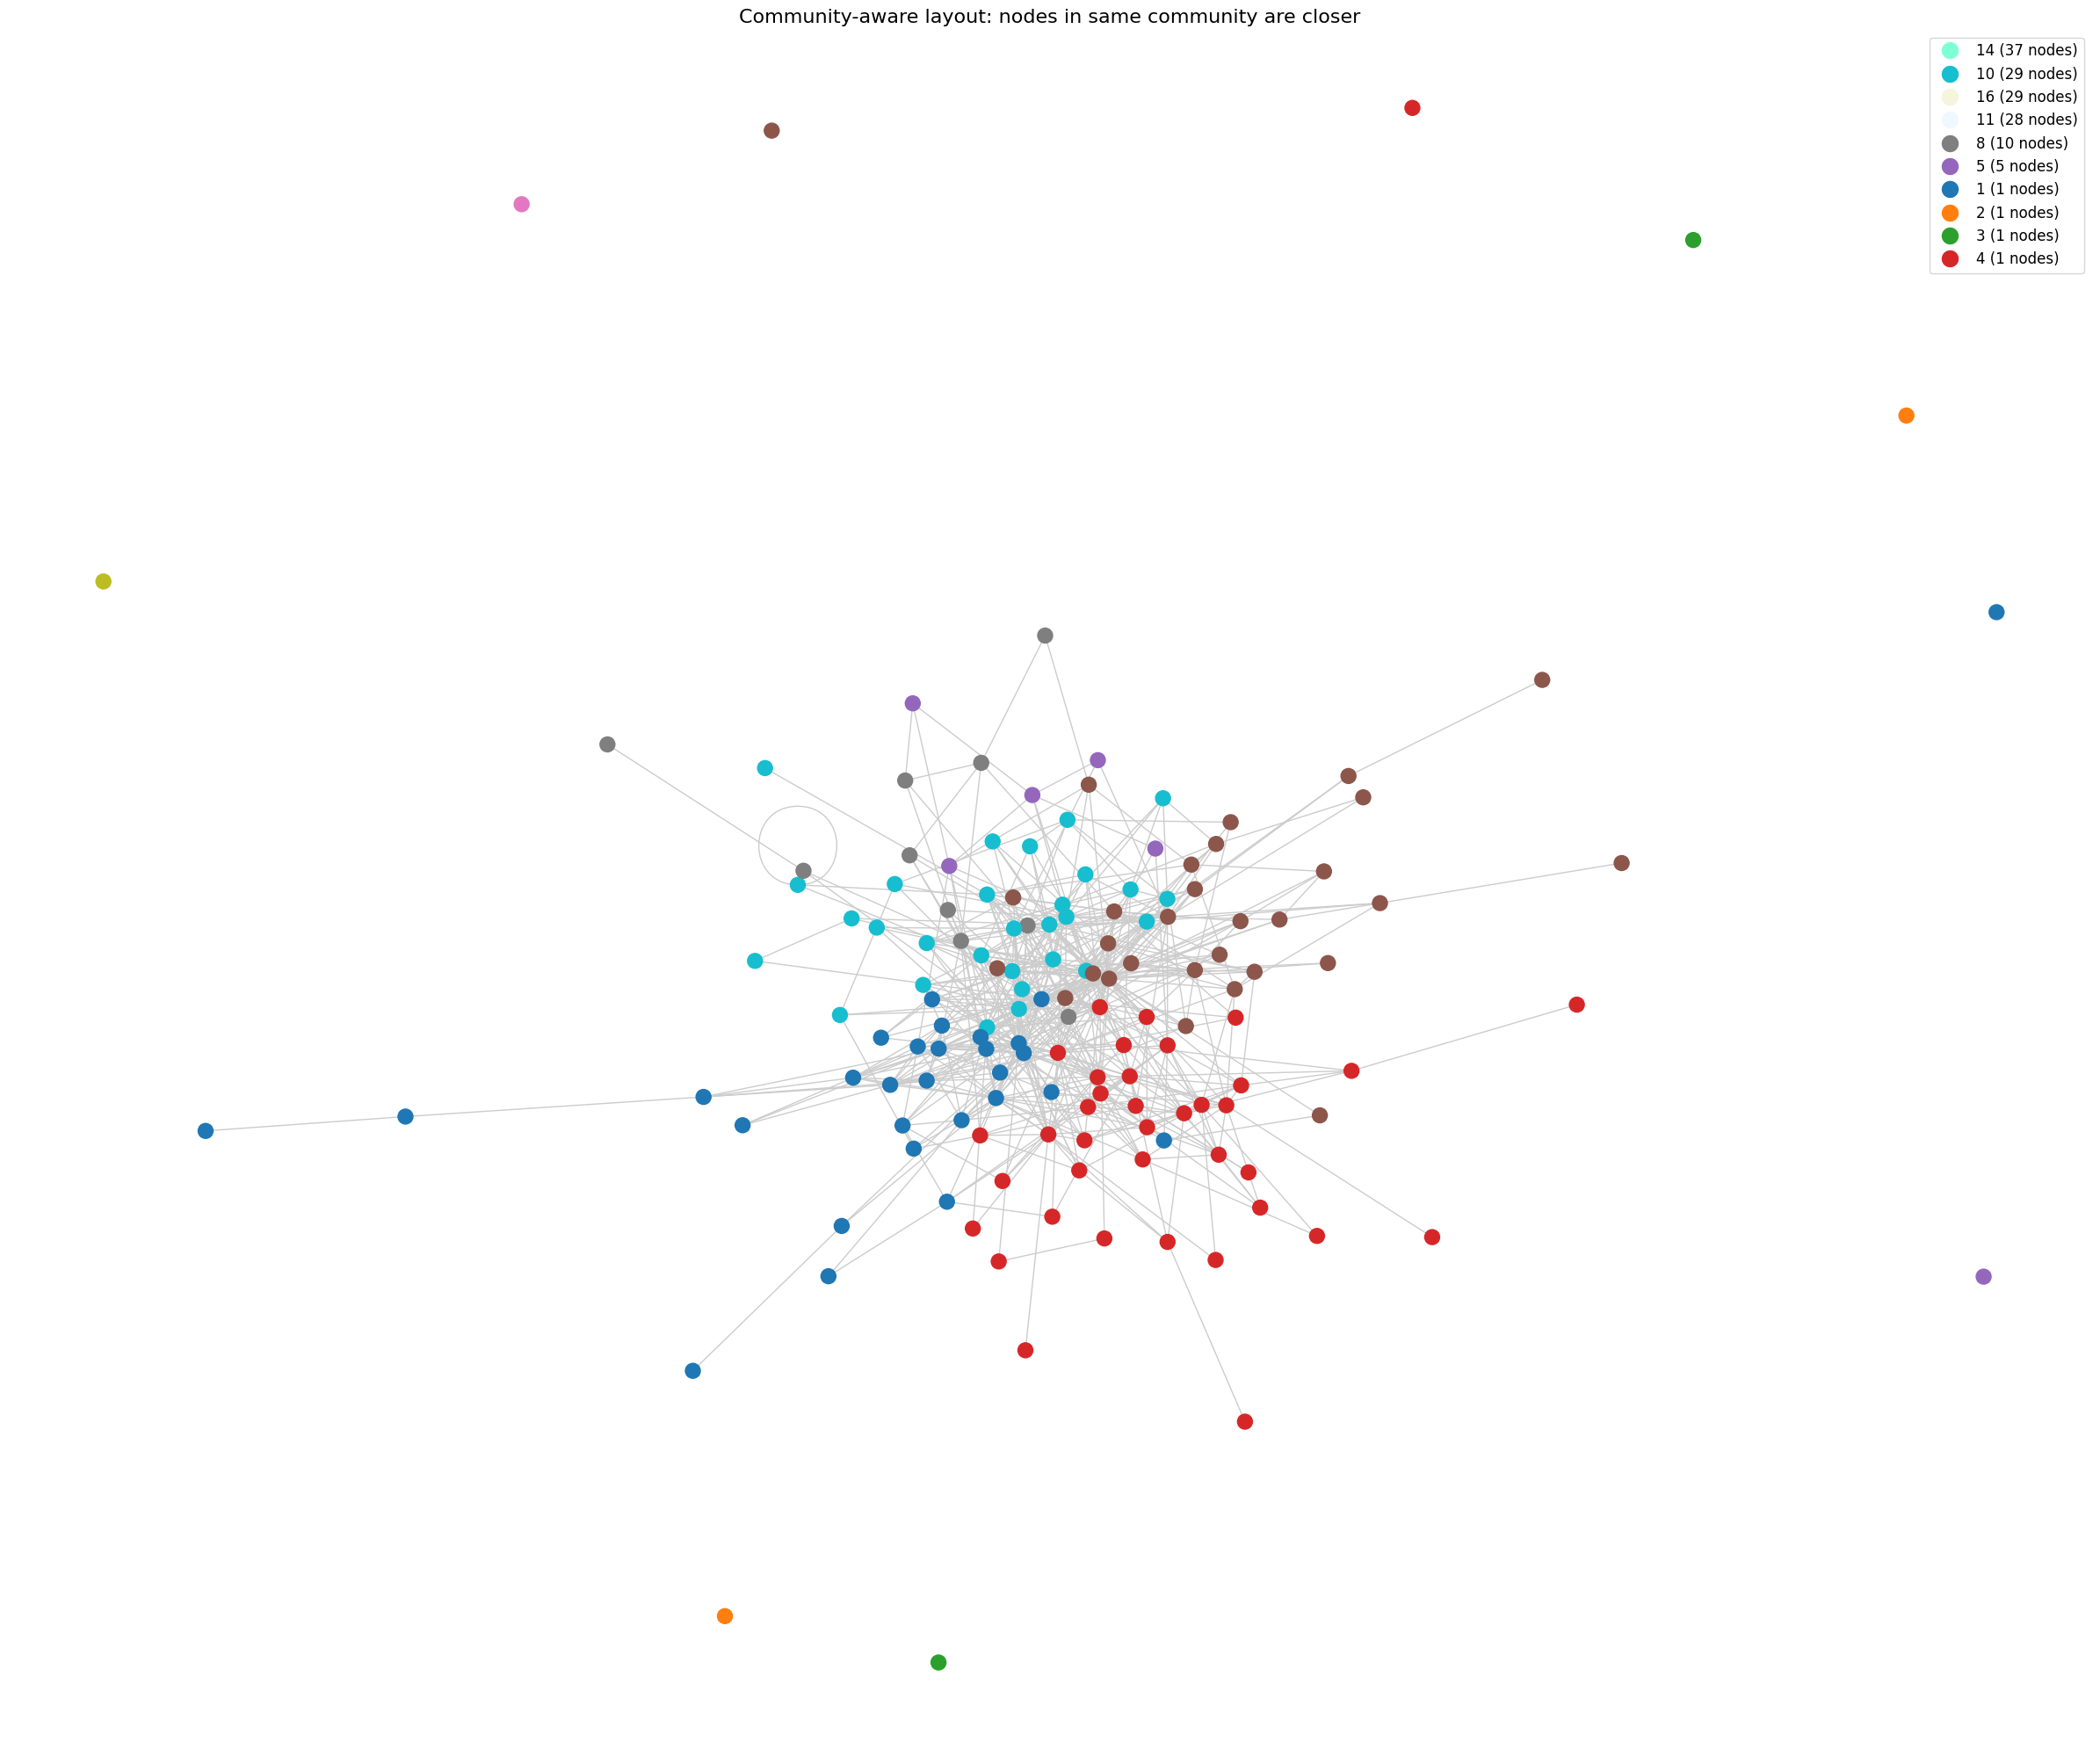

In [165]:
plot_community_aware(louvain_dict, subnetwork)

<center>Figure 7: Custom layout colored by community for the Louvain partition</center>

##### *Corresponding text from Week 7 exercise:* ##### 

*Keep using the community labels from above, but now visualize only the backbone-edges from your favorite network backbone from Week 5. Do the community correspond to the backbone structure you detected?*

In order to visualize the backbone-edges from the network, I download the network's backbone from Github.

In [166]:
# Load the backbone
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_assignment2/refs/heads/denisa/backbone.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    backbone = nx.read_graphml(io.BytesIO(data))
    print(f"✓ Backbone network loaded successfully!")
    print(f"  Nodes: {network.number_of_nodes()}")
    print(f"  Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"✗ Error loading network: {str(e)}")
    backbone = None

✓ Backbone network loaded successfully!
  Nodes: 484
  Edges: 6301


First, I plotted the first genre partition of the backbone with the Force Atlas algorithm.

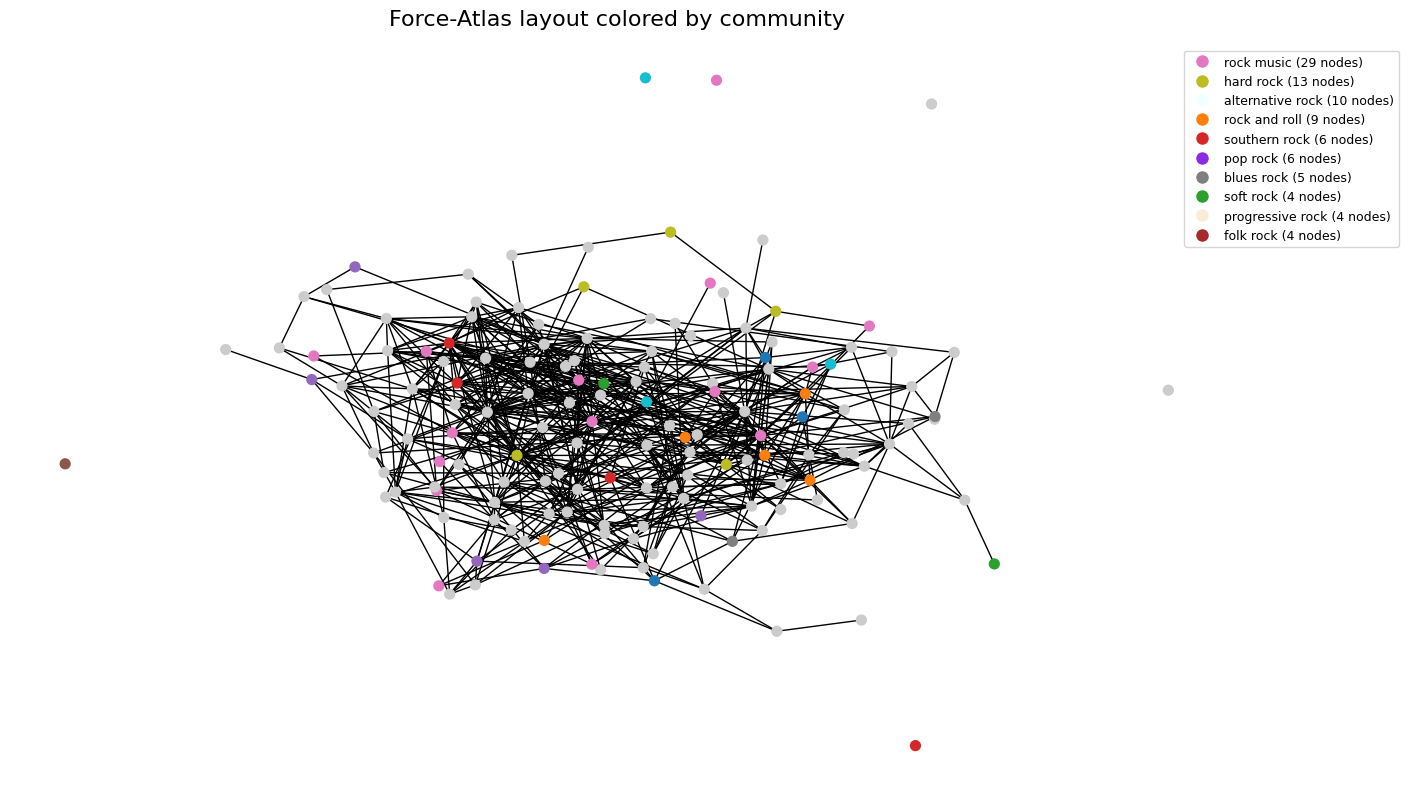

In [167]:
plot_force_atlas(first_partition, backbone)

<center>Figure 8: Backbone of the Force-Atlas layout colored by community for the first genre partition</center>

I also plotted with my custom visualization function.

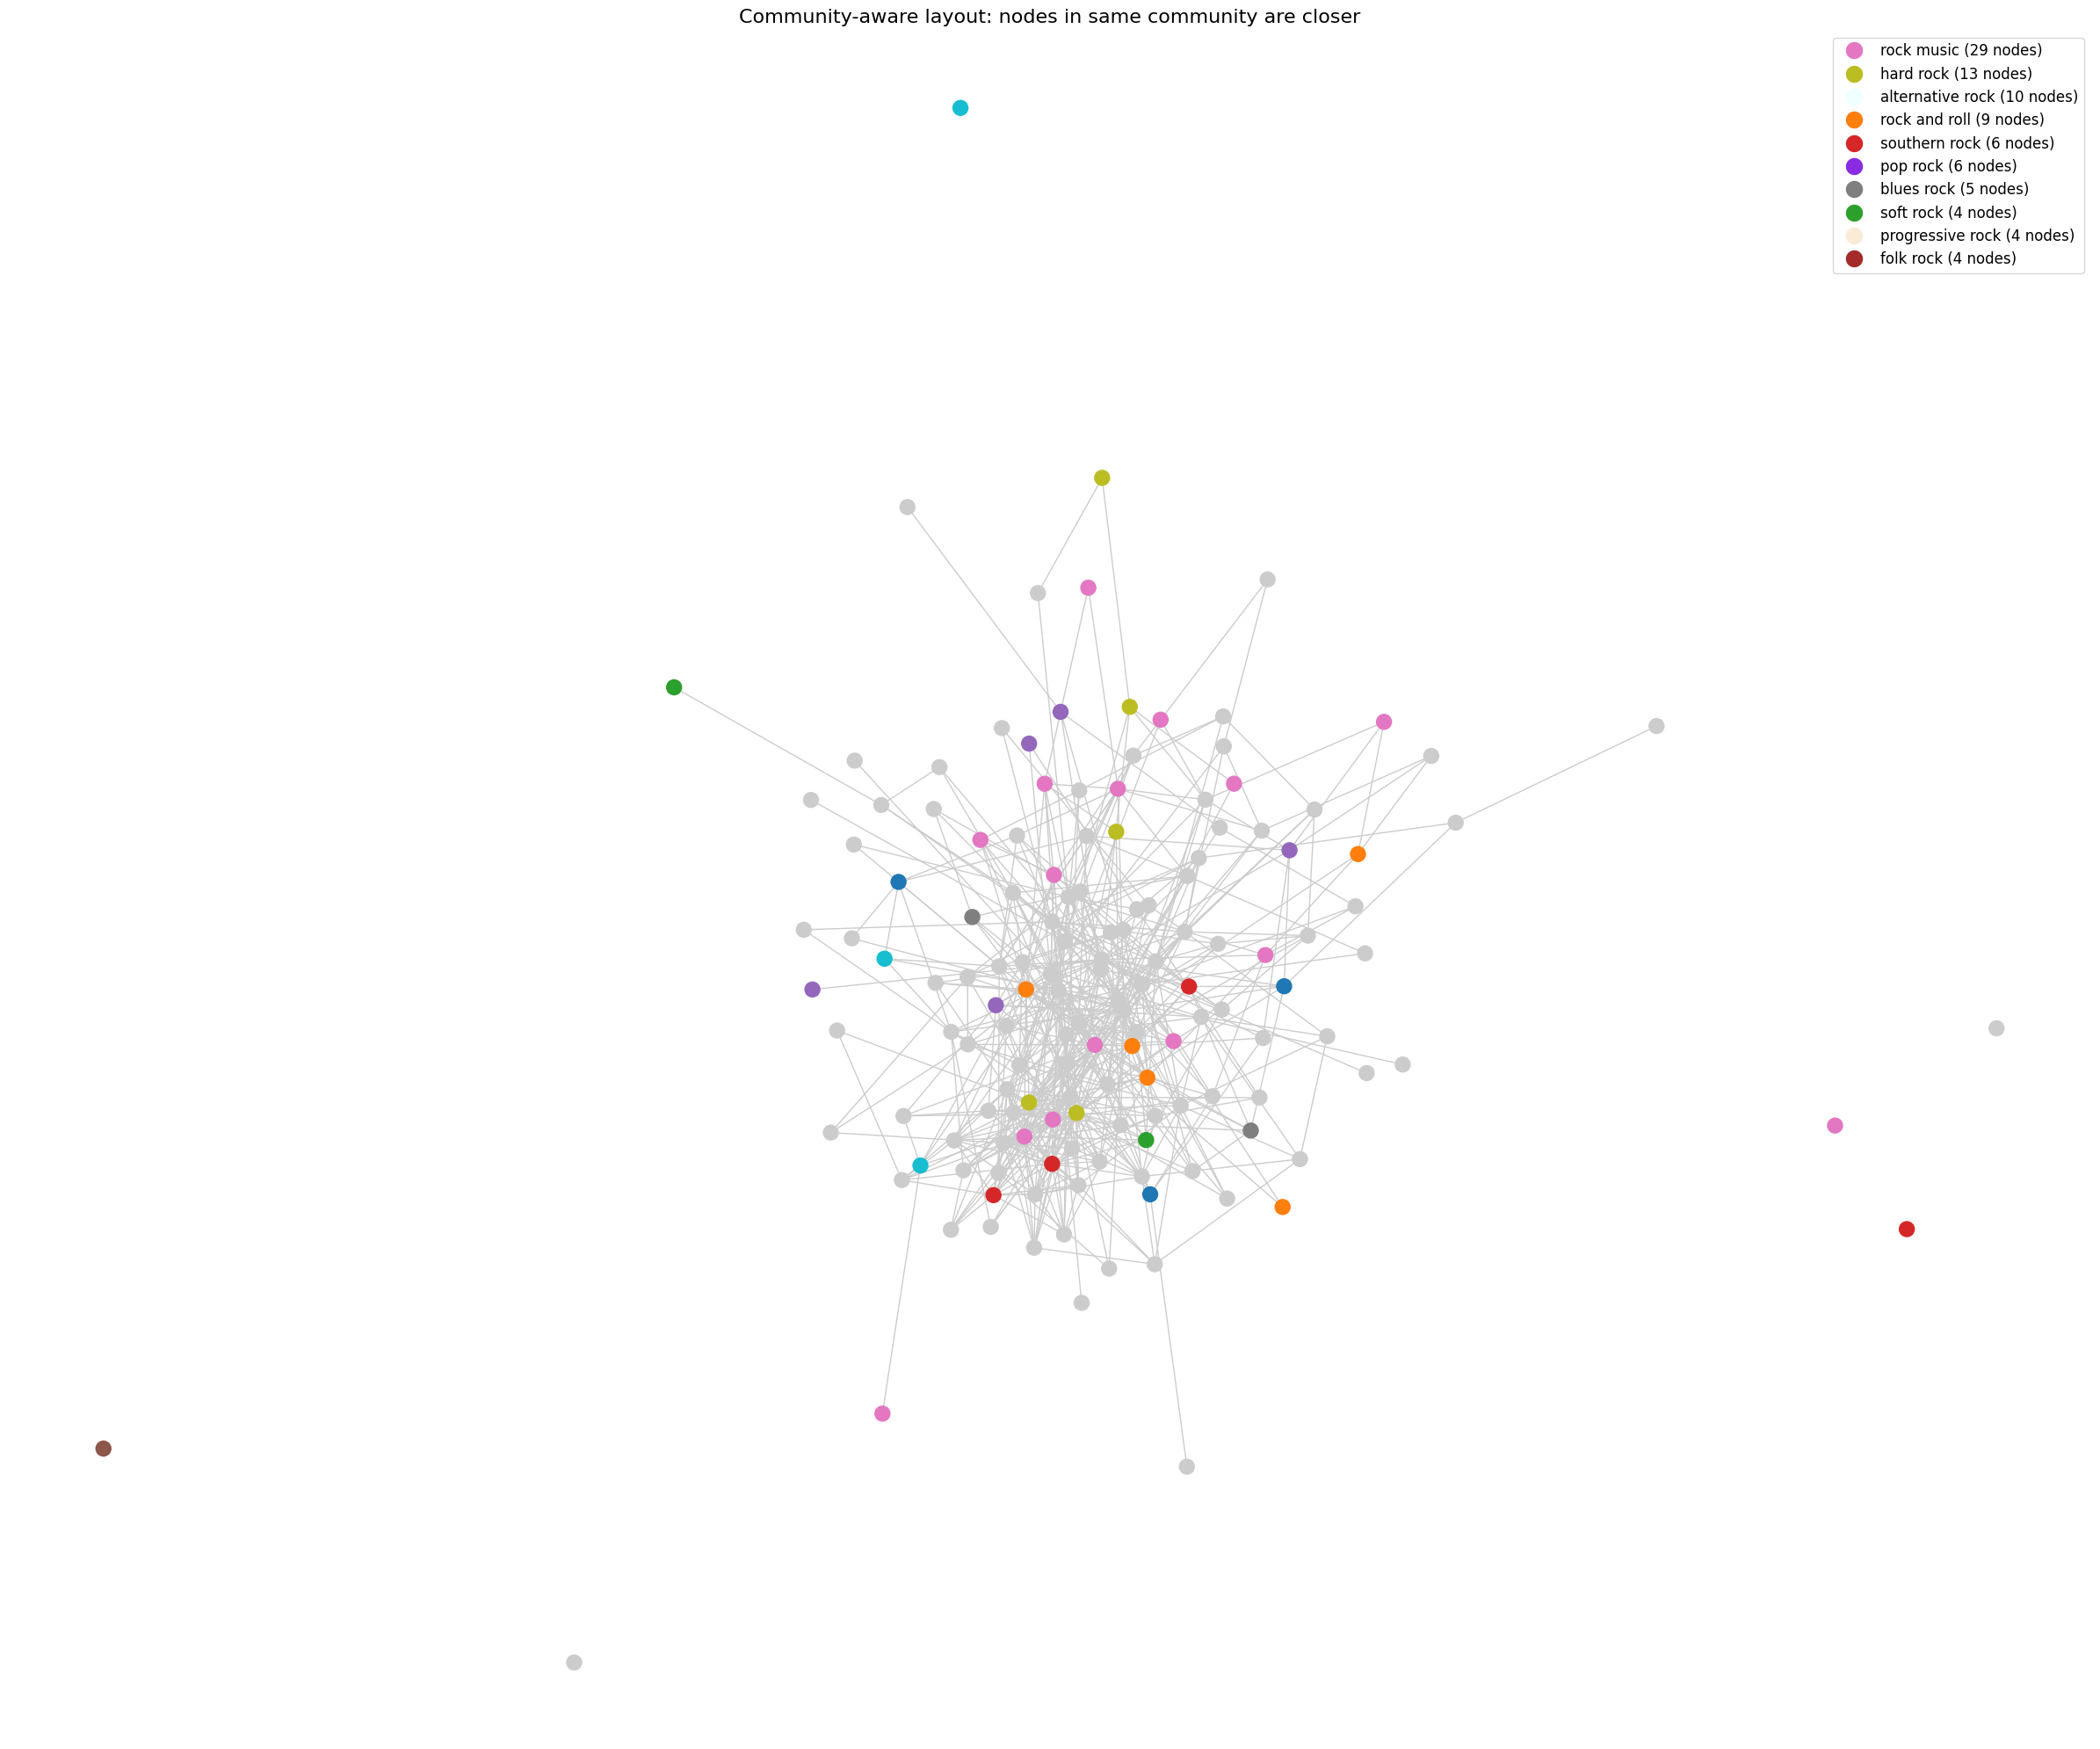

In [168]:
plot_community_aware(first_partition, backbone)

<center>Figure 9: Backbone of the custom layout colored by community for the first genre partition</center>

I plotted the Louvain partition of the backbone with Force Atlas.

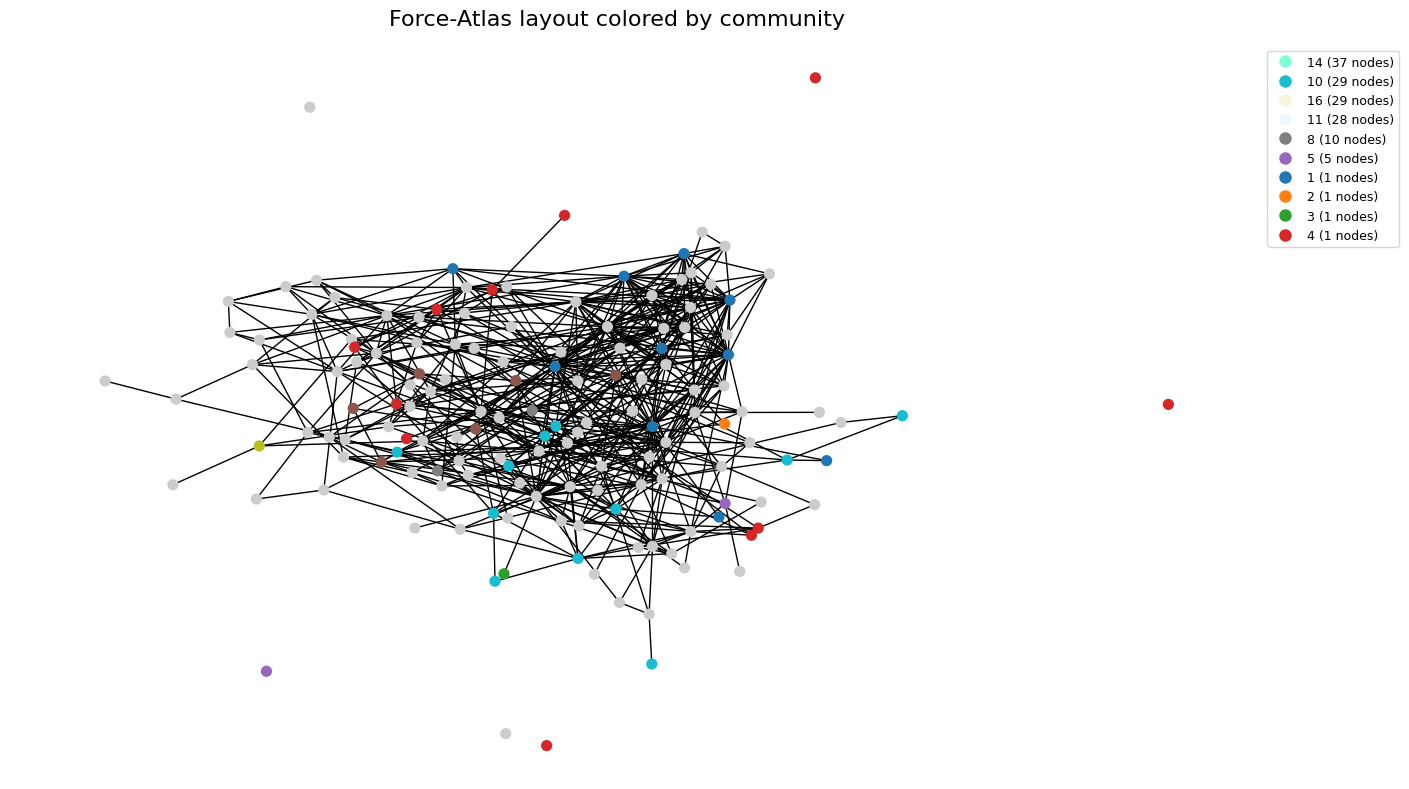

In [169]:
plot_force_atlas(louvain_dict, backbone)

<center>Figure 10: Backbone of the Force-Atlas layout colored by community for the Louvain partition</center>

Finally, I plotted with the help of my custom visualization function.

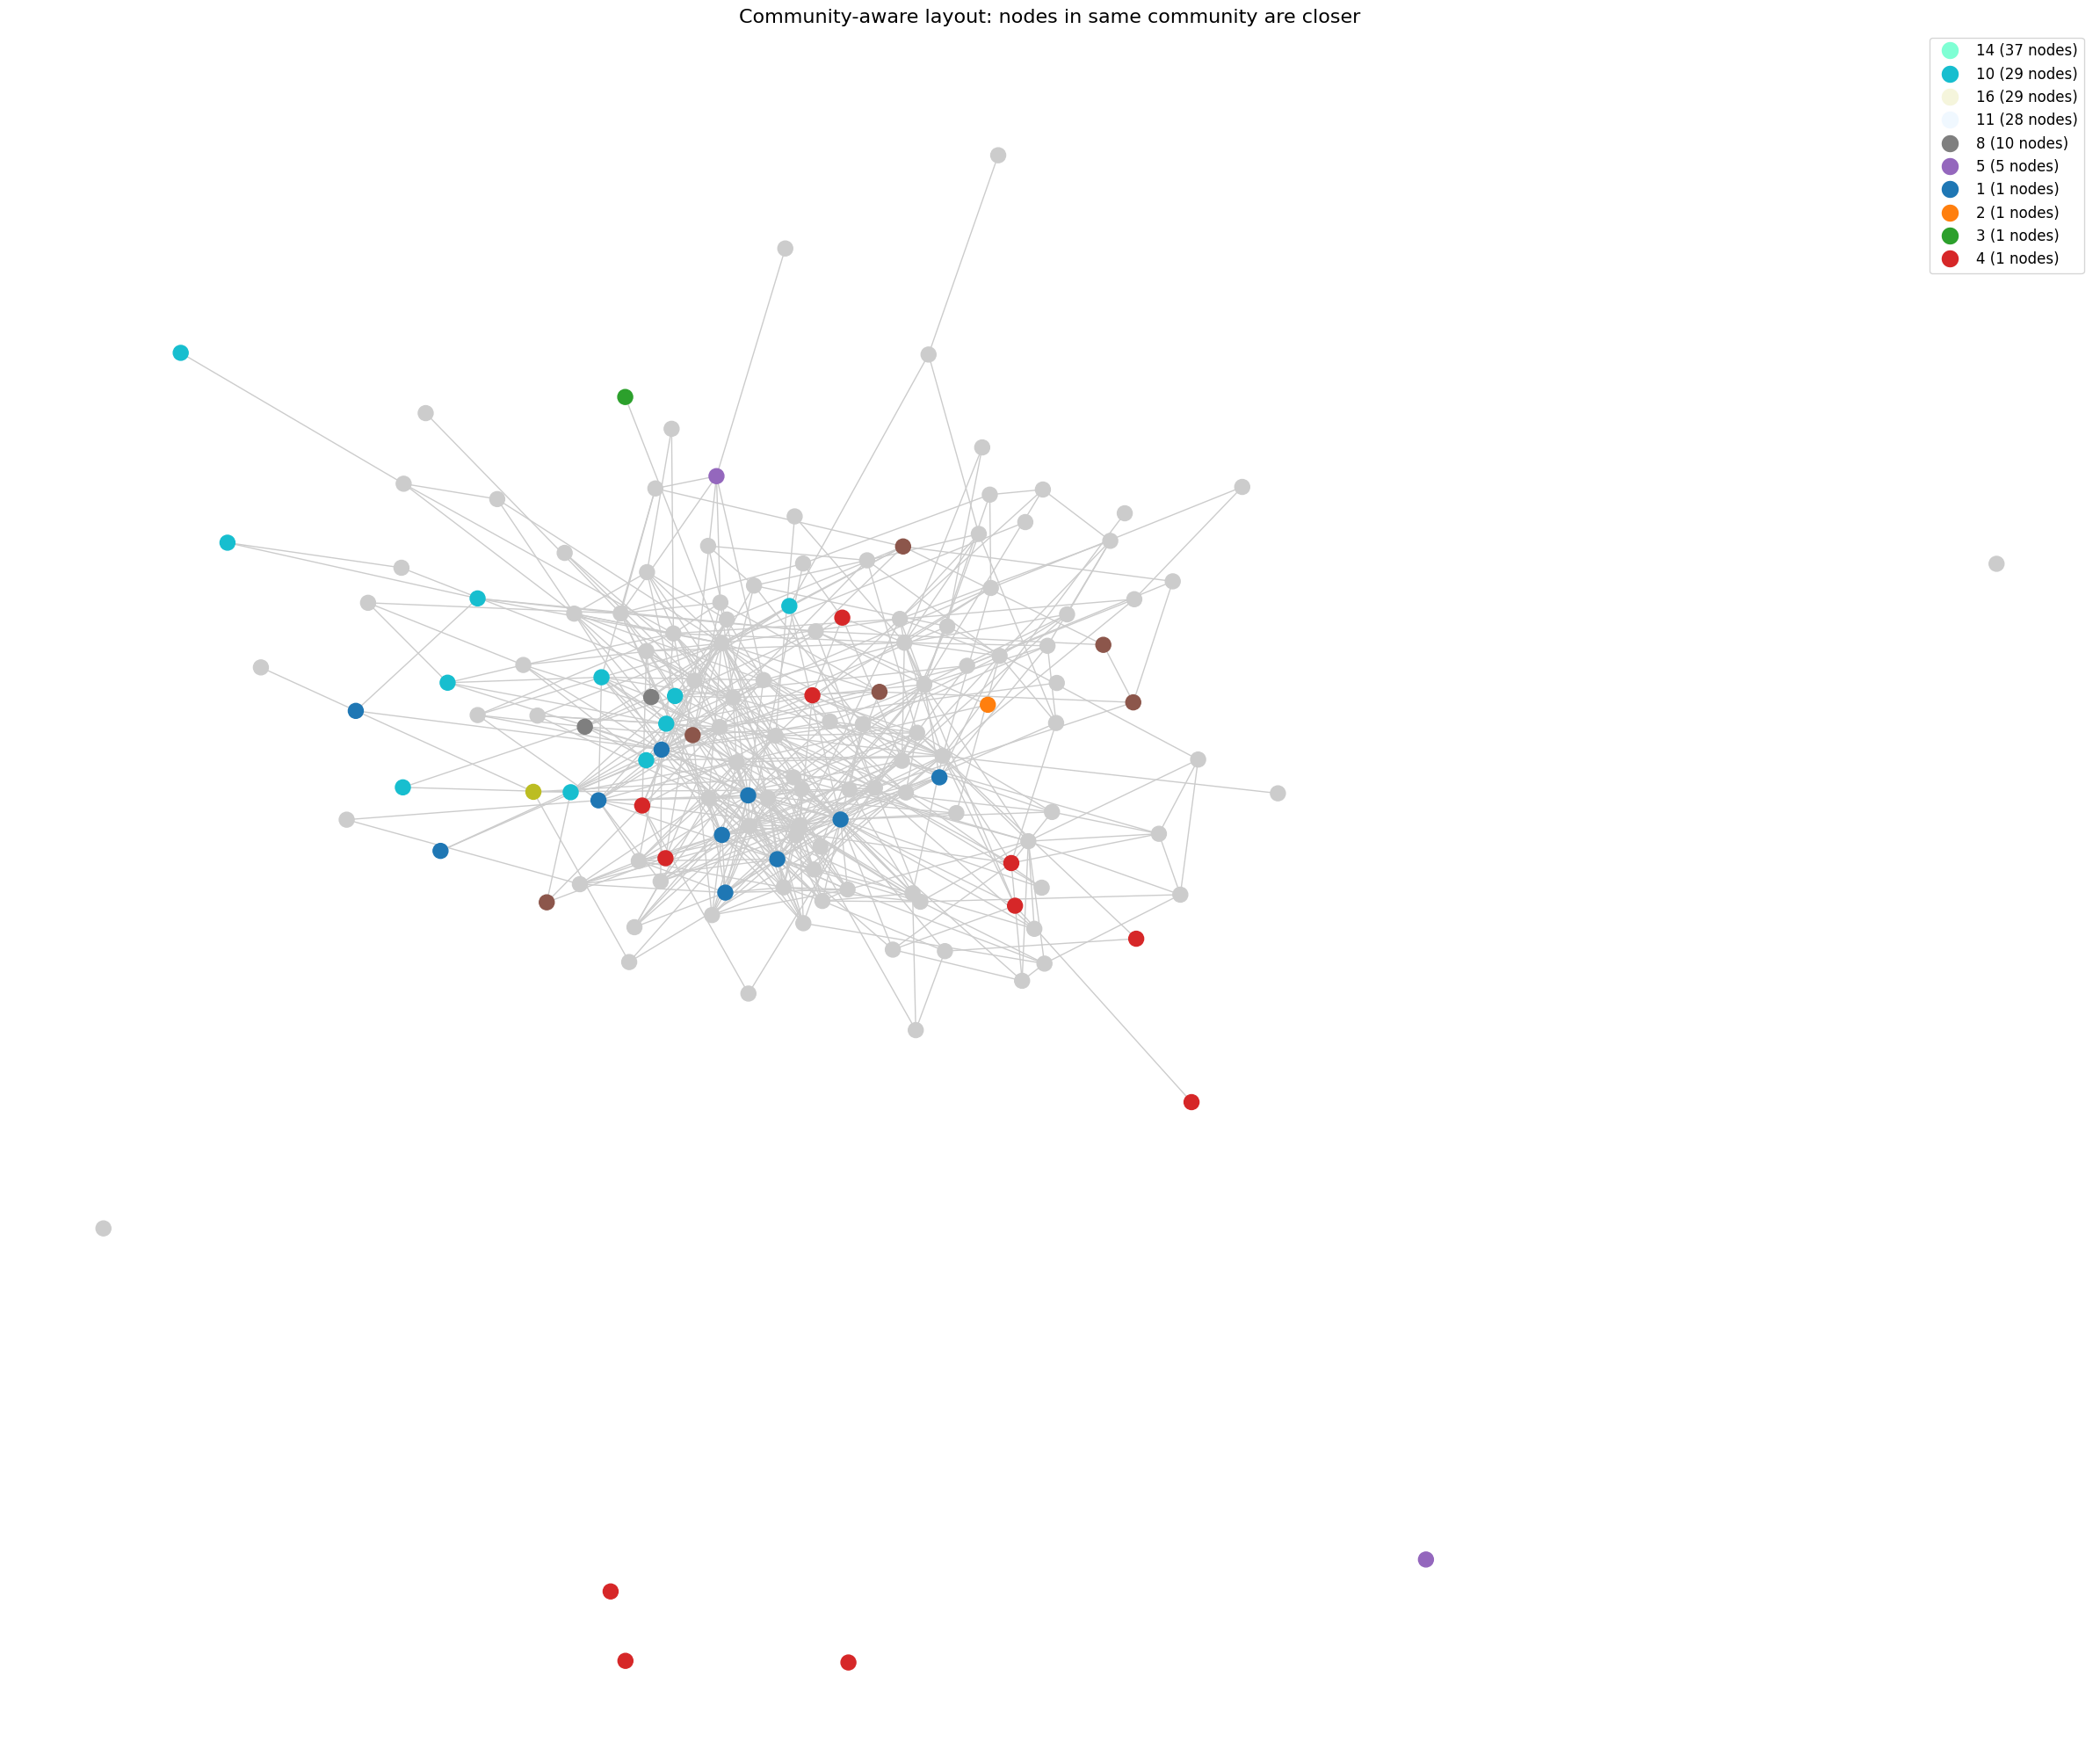

In [170]:
plot_community_aware(louvain_dict, backbone)

<center>Figure 11: Backbone of the custom layout colored by community for the Louvain partition</center>